In [88]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

In [89]:
random_seeds = [10, 13, 40, 97, 123, 256, 512, 777, 31415]
SMPO_folder_names="../output/Nominal_SMPO_Sagar_Seed"
SMPO_nominal="../output/Nominal_SMPO_Sagar_Seed42_Epoch200/"

In [90]:
#copying same roc def as tn4ml eval 
def get_roc_curve_data(y_true: np.ndarray, y_scores: np.ndarray, anomaly_det: bool = False):
    if anomaly_det:
        true_val = np.concatenate((np.ones(y_scores.shape[0]), np.zeros(y_true.shape[0])))
        pred_val = np.concatenate((y_scores, y_true))
    else:
        true_val = y_true
        pred_val = y_scores
    
    fpr, tpr, _ = roc_curve(true_val, pred_val, drop_intermediate=False)

    return fpr, tpr

In [91]:
def get_tpr_at_fpr(fpr_array, tpr_array, target_fpr=1e-5):
    """Get TPR at specific FPR value."""
    idx = np.searchsorted(fpr_array, target_fpr, side='right')
    if idx >= len(tpr_array):
        idx = -1
    return tpr_array[idx]


In [92]:
def get_fpr_tpr_for_seed(file_path):
    """Get ROC curves for all signal types for a single seed"""
    
    # Read background once (same for all signals) - FIX HERE
    bkg_norm = pd.read_csv(file_path + 'bkg_test_norm.csv', delimiter=',')#.values.flatten()

    bkg_score = np.abs(bkg_norm - np.median(bkg_norm))
    
    # Define signal types
    signals = {
        'a4l': 'a4l_norm.csv',
        'LQ': 'lq_norm.csv',
        'Htaunu': 'htnu_norm.csv',
        'Htautau': 'htt_norm.csv'
    }
    
    fpr_dict = {}
    tpr_dict = {}
    auc_dict = {}
    tpr_at_1e5 = {}
    
    for signal_name, filename in signals.items():
        signal_norm = pd.read_csv(file_path + filename, delimiter=',')#.values.flatten()
        signal_score = np.abs(signal_norm - np.median(signal_norm)) # FIX HERE
        
        fpr, tpr = get_roc_curve_data(bkg_score, signal_score, anomaly_det=True)
        
        fpr_dict[signal_name] = fpr
        tpr_dict[signal_name] = tpr
        auc_dict[signal_name] = auc(fpr, tpr)
        tpr_at_1e5[signal_name] = get_tpr_at_fpr(fpr, tpr, target_fpr=1e-5)*100

        print(f" Seed: {file_path.split('Seed')[-1]}, Signal: {signal_name}, AUC: {auc_dict[signal_name]:.2f}, TPR at 1e-5: {tpr_at_1e5[signal_name]:.2f}")
    print("**********************************************************")

    
    return fpr_dict, tpr_dict, auc_dict

In [93]:
SMPO_nominal_fpr_tpr = get_fpr_tpr_for_seed(SMPO_nominal)

 Seed: 42_Epoch200/, Signal: a4l, AUC: 0.91, TPR at 1e-5: 6.19
 Seed: 42_Epoch200/, Signal: LQ, AUC: 0.86, TPR at 1e-5: 0.10
 Seed: 42_Epoch200/, Signal: Htaunu, AUC: 0.88, TPR at 1e-5: 0.10
 Seed: 42_Epoch200/, Signal: Htautau, AUC: 0.79, TPR at 1e-5: 0.11
**********************************************************


In [94]:
def collect_ensemble_rocs(base_path, seeds):
    """Collect ROC curves across all seeds"""
    
    signals = ['a4l', 'LQ', 'Htaunu', 'Htautau']
    
    # Storage for ensemble
    ensemble_data = {sig: {'fprs': [], 'tprs': [], 'aucs': []} for sig in signals}
    
    for seed in seeds:
        file_path = f"{base_path}{seed}/"  # Adjust path structure as needed
        fpr_dict, tpr_dict, auc_dict = get_fpr_tpr_for_seed(file_path)
        
        # Collect for ensemble
        for sig in signals:
            ensemble_data[sig]['fprs'].append(fpr_dict[sig])
            ensemble_data[sig]['tprs'].append(tpr_dict[sig])
            ensemble_data[sig]['aucs'].append(auc_dict[sig])
    
    return ensemble_data




In [95]:
def compute_roc_bands(ensemble_data, signal_name, nominal_fpr):
    """Compute uncertainty bands for a specific signal"""
    
    # Common FPR points for interpolation
    mean_fpr = nominal_fpr#np.linspace(0, 1, 100)
    
    tprs_interp = []
    for fpr, tpr in zip(ensemble_data[signal_name]['fprs'], 
                        ensemble_data[signal_name]['tprs']):
        interp_tpr = np.interp(mean_fpr, fpr, tpr)
        interp_tpr[0] = 0.0
        tprs_interp.append(interp_tpr)
    
    tprs_interp = np.array(tprs_interp)
    
    return {
        'mean_fpr': mean_fpr,
        'tpr_lower': np.percentile(tprs_interp, 2.5, axis=0),
        'tpr_upper': np.percentile(tprs_interp, 97.5, axis=0),
        'tpr_mean': tprs_interp.mean(axis=0),
        'auc_mean': np.mean(ensemble_data[signal_name]['aucs']),
        'auc_std': np.std(ensemble_data[signal_name]['aucs'])
    }


In [96]:
# Usage:
SMPO_ensemble_data = collect_ensemble_rocs(
    SMPO_folder_names,
    random_seeds,
)

 Seed: 10/, Signal: a4l, AUC: 0.84, TPR at 1e-5: 1.57
 Seed: 10/, Signal: LQ, AUC: 0.77, TPR at 1e-5: 0.04
 Seed: 10/, Signal: Htaunu, AUC: 0.80, TPR at 1e-5: 0.06
 Seed: 10/, Signal: Htautau, AUC: 0.72, TPR at 1e-5: 0.07
**********************************************************
 Seed: 13/, Signal: a4l, AUC: 0.86, TPR at 1e-5: 3.43
 Seed: 13/, Signal: LQ, AUC: 0.80, TPR at 1e-5: 0.06
 Seed: 13/, Signal: Htaunu, AUC: 0.85, TPR at 1e-5: 0.06
 Seed: 13/, Signal: Htautau, AUC: 0.75, TPR at 1e-5: 0.06
**********************************************************
 Seed: 40/, Signal: a4l, AUC: 0.92, TPR at 1e-5: 4.61
 Seed: 40/, Signal: LQ, AUC: 0.79, TPR at 1e-5: 0.07
 Seed: 40/, Signal: Htaunu, AUC: 0.83, TPR at 1e-5: 0.06
 Seed: 40/, Signal: Htautau, AUC: 0.72, TPR at 1e-5: 0.07
**********************************************************
 Seed: 97/, Signal: a4l, AUC: 0.92, TPR at 1e-5: 2.33
 Seed: 97/, Signal: LQ, AUC: 0.84, TPR at 1e-5: 0.06
 Seed: 97/, Signal: Htaunu, AUC: 0.88, TPR at 1e-5

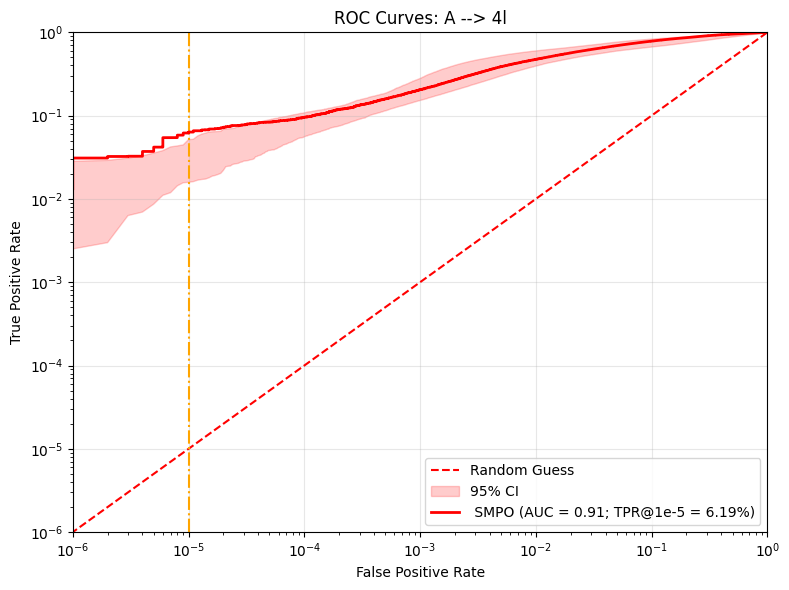

In [97]:
# Plot for a specific signal
signal = 'a4l'

SMPO_bands = compute_roc_bands(SMPO_ensemble_data, signal, SMPO_nominal_fpr_tpr[0][signal])

plt.figure(figsize=(8, 6))
plt.xscale('log')
plt.yscale('log')
plt.xlim([1e-6, 1.0])
plt.ylim([1e-6, 1.0])
plt.plot([0, 1], [0, 1], color="red", linestyle="--", label="Random Guess")
plt.axvline(1e-5, color="orange", linestyle="-.")

plt.fill_between(SMPO_bands['mean_fpr'], SMPO_bands['tpr_lower'], SMPO_bands['tpr_upper'],
                 alpha=0.2, color='red', label='95% CI')
plt.plot(SMPO_nominal_fpr_tpr[0][signal], SMPO_nominal_fpr_tpr[1][signal], color="red", lw=2, label=f" SMPO (AUC = {auc(SMPO_nominal_fpr_tpr[0][signal],SMPO_nominal_fpr_tpr[1][signal]):.2f}; TPR@1e-5 = {get_tpr_at_fpr(SMPO_nominal_fpr_tpr[0][signal], SMPO_nominal_fpr_tpr[1][signal], target_fpr=1e-5)*100:.2f}%)")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves: A --> 4l")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("../output/ensemble_roc_a4l.pdf", bbox_inches="tight")
plt.show()

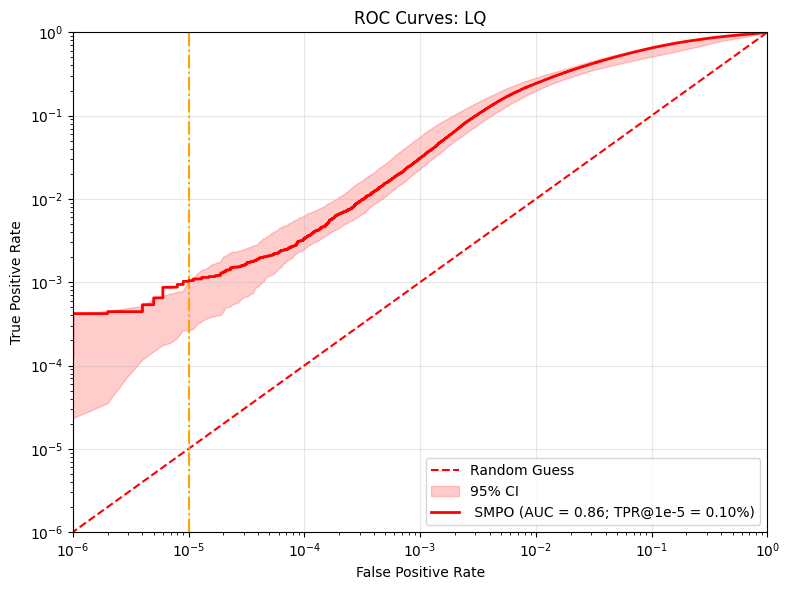

In [98]:
# Plot for a specific signal
signal = 'LQ'

SMPO_bands = compute_roc_bands(SMPO_ensemble_data, signal, SMPO_nominal_fpr_tpr[0][signal])

plt.figure(figsize=(8, 6))
plt.xscale('log')
plt.yscale('log')
plt.xlim([1e-6, 1.0])
plt.ylim([1e-6, 1.0])
plt.plot([0, 1], [0, 1], color="red", linestyle="--", label="Random Guess")
plt.axvline(1e-5, color="orange", linestyle="-.")


plt.fill_between(SMPO_bands['mean_fpr'], SMPO_bands['tpr_lower'], SMPO_bands['tpr_upper'],
                 alpha=0.2, color='red', label='95% CI')
plt.plot(SMPO_nominal_fpr_tpr[0][signal], SMPO_nominal_fpr_tpr[1][signal], color="red", lw=2, label=f" SMPO (AUC = {auc(SMPO_nominal_fpr_tpr[0][signal],SMPO_nominal_fpr_tpr[1][signal]):.2f}; TPR@1e-5 = {get_tpr_at_fpr(SMPO_nominal_fpr_tpr[0][signal], SMPO_nominal_fpr_tpr[1][signal], target_fpr=1e-5)*100:.2f}%)")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves: LQ")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("../output/ensemble_roc_LQ.pdf", bbox_inches="tight")
plt.show()

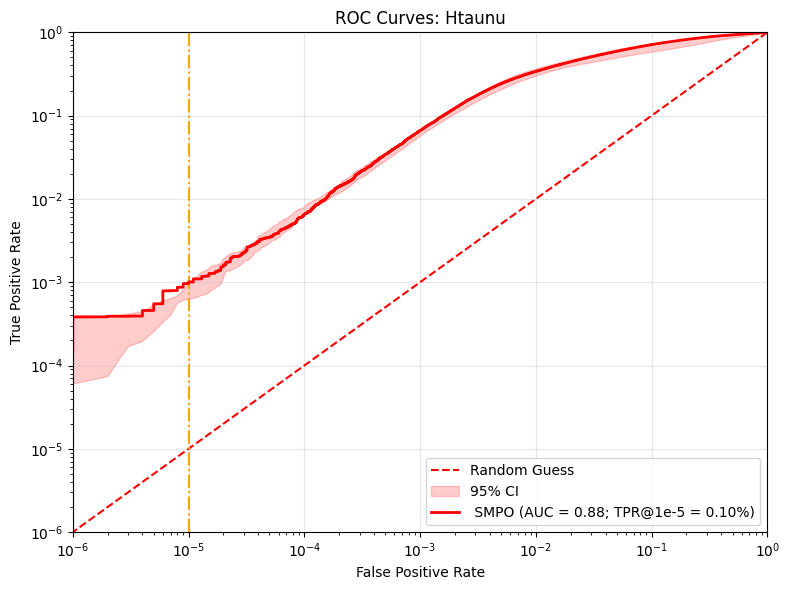

In [99]:
# Plot for a specific signal
signal = 'Htaunu'

SMPO_bands = compute_roc_bands(SMPO_ensemble_data, signal, SMPO_nominal_fpr_tpr[0][signal])

plt.figure(figsize=(8, 6))
plt.xscale('log')
plt.yscale('log')
plt.xlim([1e-6, 1.0])
plt.ylim([1e-6, 1.0])
plt.plot([0, 1], [0, 1], color="red", linestyle="--", label="Random Guess")
plt.axvline(1e-5, color="orange", linestyle="-.")


plt.fill_between(SMPO_bands['mean_fpr'], SMPO_bands['tpr_lower'], SMPO_bands['tpr_upper'],
                 alpha=0.2, color='red', label='95% CI')
plt.plot(SMPO_nominal_fpr_tpr[0][signal], SMPO_nominal_fpr_tpr[1][signal], color="red", lw=2, label=f" SMPO (AUC = {auc(SMPO_nominal_fpr_tpr[0][signal],SMPO_nominal_fpr_tpr[1][signal]):.2f}; TPR@1e-5 = {get_tpr_at_fpr(SMPO_nominal_fpr_tpr[0][signal], SMPO_nominal_fpr_tpr[1][signal], target_fpr=1e-5)*100:.2f}%)")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves: Htaunu")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("../output/ensemble_roc_Htaunu.pdf", bbox_inches="tight")
plt.show()

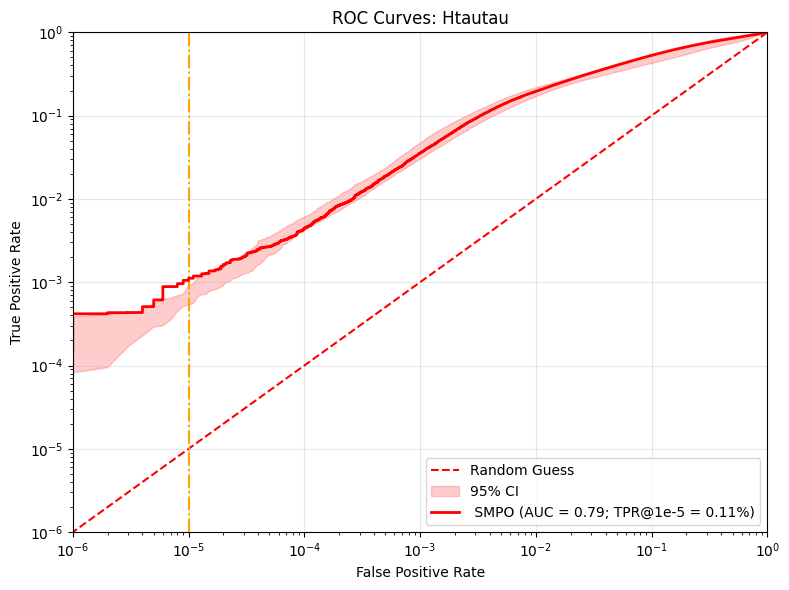

In [100]:
# Plot for a specific signal
signal = 'Htautau'

SMPO_bands = compute_roc_bands(SMPO_ensemble_data, signal, SMPO_nominal_fpr_tpr[0][signal])

plt.figure(figsize=(8, 6))
plt.xscale('log')
plt.yscale('log')
plt.xlim([1e-6, 1.0])
plt.ylim([1e-6, 1.0])
plt.plot([0, 1], [0, 1], color="red", linestyle="--", label="Random Guess")
plt.axvline(1e-5, color="orange", linestyle="-.")

plt.fill_between(SMPO_bands['mean_fpr'], SMPO_bands['tpr_lower'], SMPO_bands['tpr_upper'],
                 alpha=0.2, color='red', label='95% CI')
plt.plot(SMPO_nominal_fpr_tpr[0][signal], SMPO_nominal_fpr_tpr[1][signal], color="red", lw=2, label=f" SMPO (AUC = {auc(SMPO_nominal_fpr_tpr[0][signal],SMPO_nominal_fpr_tpr[1][signal]):.2f}; TPR@1e-5 = {get_tpr_at_fpr(SMPO_nominal_fpr_tpr[0][signal], SMPO_nominal_fpr_tpr[1][signal], target_fpr=1e-5)*100:.2f}%)")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves: Htautau")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("../output/ensemble_roc_Htautau.pdf", bbox_inches="tight")
plt.show()